# Reward-prediction evidence

**Purpose.** Keep the evidence for reward-prediction pipeline in one reproducible place. Evidence notebook, not a training notebook.

The model predicts immediate reward from the pre-action belief $b_t$ and current action $a_t$, and beats a constant-mean baseline on two held-out file splits. 

In [1]:
# move notebook to the root and check gpu availability
%cd /workspaces/tesis_v4

from pathlib import Path

# Run this notebook with the repository root as the working directory.
ROOT = Path.cwd()
if not (ROOT / 'src' / 'rwm').exists():
    raise RuntimeError('Open Jupyter from the repository root: jupyter lab --ip=0.0.0.0 --no-browser')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

plt.style.use('default')
print(f'PyTorch: {torch.__version__} | CUDA available: {torch.cuda.is_available()}')

/workspaces/tesis_v4
PyTorch: 2.7.0+cu128 | CUDA available: True


## Reproduce the anchor experiment

In [ ]:
# Writes a structured run with config, dataset manifest, metrics, probes, and checkpoints. 
!python scripts/evaluate_reward_prediction.py \
	--beta 0.0 --epochs 10 --batch-size 8 \
	--seed 42 --max-val-windows 256 \
	--out runs/component_refinement/00_reward_anchor_pre_kl_fix/seed_42/reproduction_seed42

Run directory: runs/stage2_confirmation_seed42
Train: 16 files, 4040 windows
Val:   4 files, 256 windows
/opt/conda/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
[Epoch 1] train_mse=0.5422 train_kl=0.3193 val_mse=0.5573 time=41.4s            
[Epoch 2] train_mse=0.5104 train_kl=0.4713 val_mse=0.5026 time=40.5s            
[Epoch 3] train_mse=0.4883 train_kl=0.6257 val_mse=0.4827 time=40.4s            
[Epoch 4] train_mse=0.4747 train_kl=0.7514 val_mse=0.4754 time=40.7s            
[Epoch 5] skipped ckpt: val_mse=0.4820 best=0.4754                              
[Epoch 5] train_mse=0.4656 train_kl=0.8735 val_mse=0.4820 time=41.7s
[Epoch 6] train_mse=0.4622 train_kl=0.9920 val_mse=0.4711 time=42.7s            
[Epoch 7] train_mse=0.4535 train_kl=1.0832 val_mse=0.4650 time=42.2s            
[Epoch 8] skipped ckpt: val_mse=0.4896 best=

In [5]:
# Verify the trained checkpoint still produces distinct reward predictions for distinct actions.
!python scripts/evaluate_reward_prediction.py \
	--checkpoint runs/component_refinement/00_reward_anchor_pre_kl_fix/seed_42/checkpoint_best.pt \
	--out runs/component_refinement/00_reward_anchor_pre_kl_fix/seed_42/probes/action_conditioning_rerun

Loading model...
/opt/conda/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
Loaded trained checkpoint: runs/stage2_confirmation_seed42/checkpoint_best.pt

Action probe (trained model, belief-fixed):
     all zeros: 0.120066
    full steer: 0.090129
      full gas: 0.117583
    full brake: 0.096654
Unique predictions: 4/4

Done. Results saved to runs/reward_baseline_seed42_action_probe/action_probe_results.json


## Anchor results

Both runs use 256 bounded validation windows, 10 epochs, and $Beta=0$ (reward-only diagnostic). The baseline is the training-set constant mean reward.

In [6]:
results = pd.DataFrame([
    {'seed': 42, 'train_windows': 4040, 'val_windows': 256, 'val_mse': 0.4720, 'baseline_mse': 0.5634, 'time_s': 500},
    {'seed': 43, 'train_windows': 4304, 'val_windows': 256, 'val_mse': 0.5390, 'baseline_mse': 0.6295, 'time_s': 536},
])
results['model_baseline_ratio'] = results.val_mse / results.baseline_mse
results['improvement_pct'] = (1 - results.model_baseline_ratio) * 100
results.style.format({'val_mse': '{:.4f}', 'baseline_mse': '{:.4f}', 'model_baseline_ratio': '{:.3f}', 'improvement_pct': '{:.1f}%'})

,seed,train_windows,val_windows,val_mse,baseline_mse,time_s,model_baseline_ratio,improvement_pct
0,42,4040,256,0.4720,0.5634,500,0.838,16.2%
1,43,4304,256,0.5390,0.6295,536,0.856,14.4%


**Interpretation.** The anchor beats the constant baseline by about 14–16% across two seed-dependent file partitions. This is a valid starting point, not a final performance result: the current data is sparse and random-policy dominated.

## Review a manually driven reward trace

In [15]:
# Generate an aligned trace with the interactive command. 
# Close the game window or press Escape; the command saves the CSV.
!SDL_AUDIODRIVER=dummy rwm test-rwm-manually \
	runs/component_refinement/00_reward_anchor_pre_kl_fix/seed_42/checkpoint_best.pt \
  	--log-path runs/evidence/manual_traces/seed42_session01/seed42_session01.csv \
  	--fps 60

/opt/conda/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
Figure(700x350)
Saved 680 aligned reward pairs to runs/manual_evidence/seed42_session01.csv


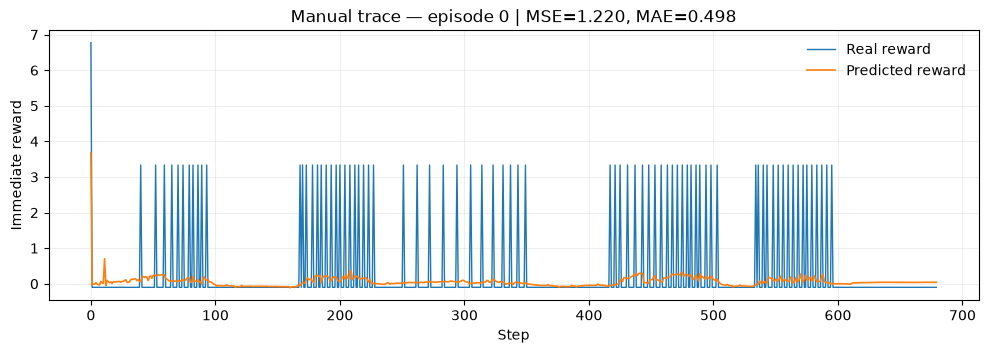

In [18]:
# Print the manual trace in a graphic

LOG_PATH = ROOT / 'runs' / 'manual_evidence' / 'seed42_session01.csv'

log = pd.read_csv(LOG_PATH)
episode_id = int(log.episode.max())
trace = log[log.episode == episode_id].copy()

if LOG_PATH.exists():
    episode_id = int(log.episode.iloc[-1])
    trace = log[log.episode == episode_id]
    mse = np.mean((trace.reward_true - trace.reward_pred) ** 2)
    mae = np.mean(np.abs(trace.reward_true - trace.reward_pred))

    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(trace.step, trace.reward_true, lw=1.0, label='Real reward')
    ax.plot(trace.step, trace.reward_pred, lw=1.2, label='Predicted reward')
    ax.set(title=f'Manual trace — episode {episode_id} | MSE={mse:.3f}, MAE={mae:.3f}',
           xlabel='Step', ylabel='Immediate reward')
    ax.legend(frameon=False)
    ax.grid(alpha=.2)
    plt.show()

## Manual-trace diagnostic

This is a qualitative distribution-shift check, **not** the thesis benchmark: the episode was human-driven and was not selected from the locked evaluation protocol.

We separate the first 50 frames (startup/camera confound) from steady driving. A reward event is any transition with real reward above the normal CarRacing baseline of `-0.1`.

In [19]:
STARTUP_STEPS = 50  # Change only when explicitly documenting a different protocol.

if LOG_PATH.exists():
    trace = log[log.episode == int(log.episode.iloc[-1])].copy()
    startup = trace.step < STARTUP_STEPS
    steady = ~startup
    reward_event = trace.reward_true > -0.1
    baseline = trace.reward_true <= -0.1

    def error_summary(name, mask):
        subset = trace.loc[mask]
        if subset.empty:
            return {'slice': name, 'n': 0, 'mse': np.nan, 'mae': np.nan,
                    'mean_true': np.nan, 'mean_pred': np.nan, 'mean_error': np.nan}
        error = subset.reward_pred - subset.reward_true
        return {
            'slice': name, 'n': len(subset),
            'mse': np.mean(error ** 2), 'mae': np.mean(np.abs(error)),
            'mean_true': subset.reward_true.mean(),
            'mean_pred': subset.reward_pred.mean(),
            'mean_error': error.mean(),  # negative = systematic underprediction
        }

    manual_diagnostic = pd.DataFrame([
        error_summary('all transitions', np.ones(len(trace), dtype=bool)),
        error_summary(f'startup (<{STARTUP_STEPS})', startup),
        error_summary('steady state', steady),
        error_summary('reward events, steady', steady & reward_event),
        error_summary('baseline -0.1, steady', steady & baseline),
    ])
    display(manual_diagnostic.style.format({
        'mse': '{:.3f}', 'mae': '{:.3f}', 'mean_true': '{:.3f}',
        'mean_pred': '{:.3f}', 'mean_error': '{:.3f}',
    }))

,slice,n,mse,mae,mean_true,mean_pred,mean_error
0,all transitions,680,1.220,0.498,0.299,0.058,-0.241
1,startup (<50),50,0.452,0.309,0.106,0.161,0.055
2,steady state,630,1.281,0.513,0.315,0.050,-0.265
3,"reward events, steady",510,1.577,0.608,0.412,0.059,-0.353
4,"baseline -0.1, steady",120,0.023,0.111,-0.100,0.011,0.111
